# 07 — Explainability (SHAP)
Student Success Analytics Platform

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import json
import pandas as pd
import mlflow
from xgboost import XGBRegressor
from src.explainability import (
    get_shap_explainer, get_shap_values,
    plot_summary, plot_bar, plot_waterfall
)

mlflow.set_experiment("student-success-platform")
print("libraries loaded")

libraries loaded


In [2]:
import sys
!{sys.executable} -m pip install shap

## Why this model, why SHAP
The XGBoost regressor is used here even though notebook 6 selected a simpler model for production. Reason: SHAP's TreeExplainer is purpose-built for tree ensembles, and XGBoost lets us show feature-level attribution in a way a single-column linear baseline cannot — there's nothing interesting to explain in a model with one input. The XGBoost model's SHAP output should confirm (or complicate) notebook 6's ablation finding: that `previous_gpa` dominates, and other features add minimal marginal signal.

In [3]:
with open("../data/processed/selected_features.json") as f:
    selected_features = json.load(f)

X_train_selected = pd.read_csv("../data/processed/X_train_selected.csv")
X_test_selected = pd.read_csv("../data/processed/X_test_selected.csv")
y_reg_train = pd.read_csv("../data/processed/y_reg_train.csv").squeeze()

# use a 500-row sample of the test set for SHAP — computing full SHAP values for 16k rows
# with 56 features is slow and visually identical to a well-chosen sample
X_sample = X_test_selected.sample(500, random_state=42).reset_index(drop=True)

print(f"training set: {X_train_selected.shape}  sample for SHAP: {X_sample.shape}")

training set: (64000, 56)  sample for SHAP: (500, 56)


In [4]:
# retrain XGBoost on the selected feature set (same params as notebook 5/6)
xgb_model = XGBRegressor(n_estimators=200, random_state=42)
xgb_model.fit(X_train_selected, y_reg_train)

explainer = get_shap_explainer(xgb_model, X_train_selected)
shap_values = get_shap_values(explainer, X_sample)

print("SHAP values computed for", len(X_sample), "test samples")

SHAP values computed for 500 test samples


## Summary plot
Each dot is one student, each row is one feature. Position on the x-axis shows whether that feature pushed the model's prediction up (positive SHAP) or down (negative SHAP) for that student. Color shows the actual feature value (red = high, blue = low). Features are ordered top-to-bottom by mean absolute SHAP value — most impactful at the top.

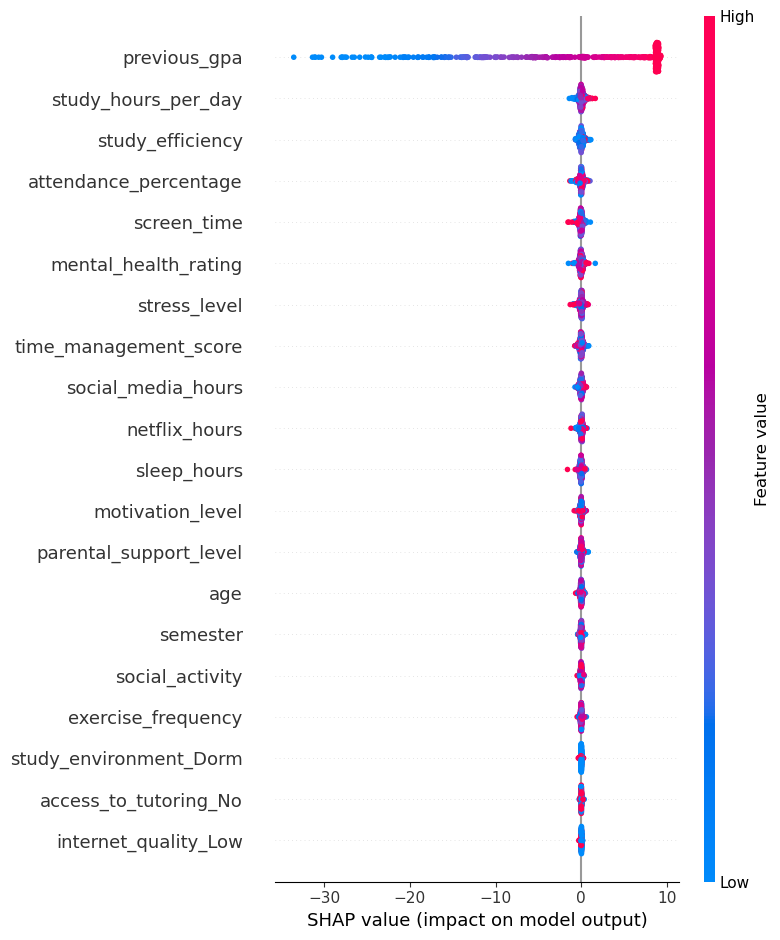

In [5]:
plot_summary(shap_values, X_sample, save_path="../data/processed/shap_summary.png")

## Bar plot — mean absolute SHAP value per feature
A simpler view of the same information: which features moved predictions the most on average, regardless of direction.

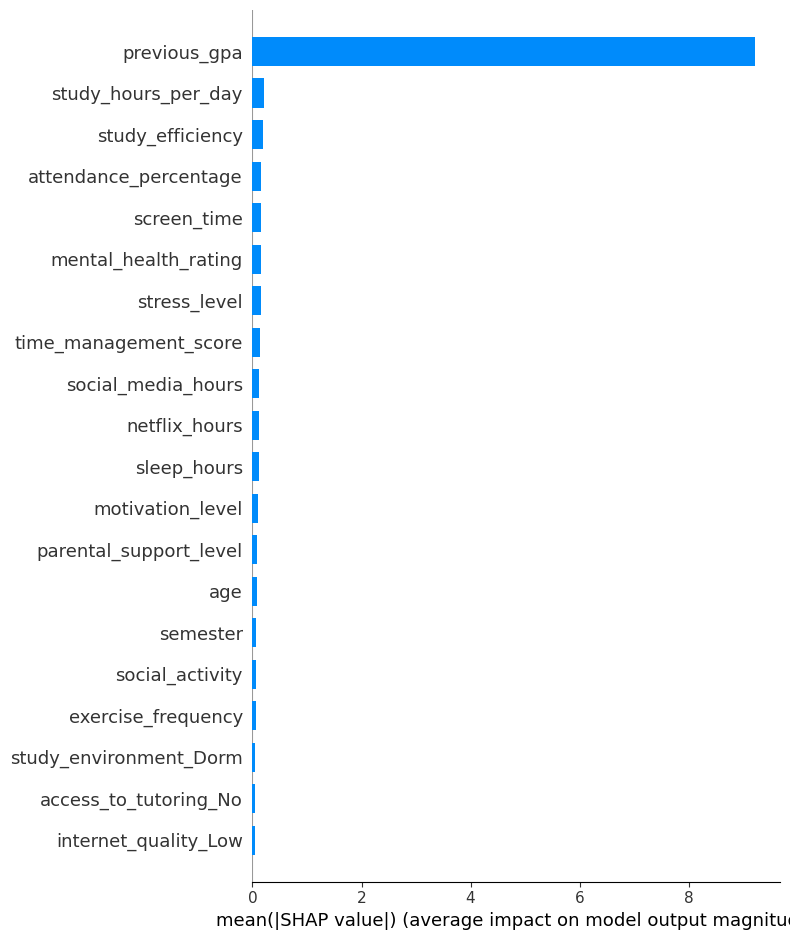

In [6]:
plot_bar(shap_values, X_sample, save_path="../data/processed/shap_bar.png")

## Waterfall plot — single prediction explained
Shows how each feature contributed to the prediction for one specific student, starting from the model's baseline (average predicted score across all students) and adding or subtracting each feature's contribution to arrive at the final prediction.

explaining student at index 367 — predicted score: 89.6


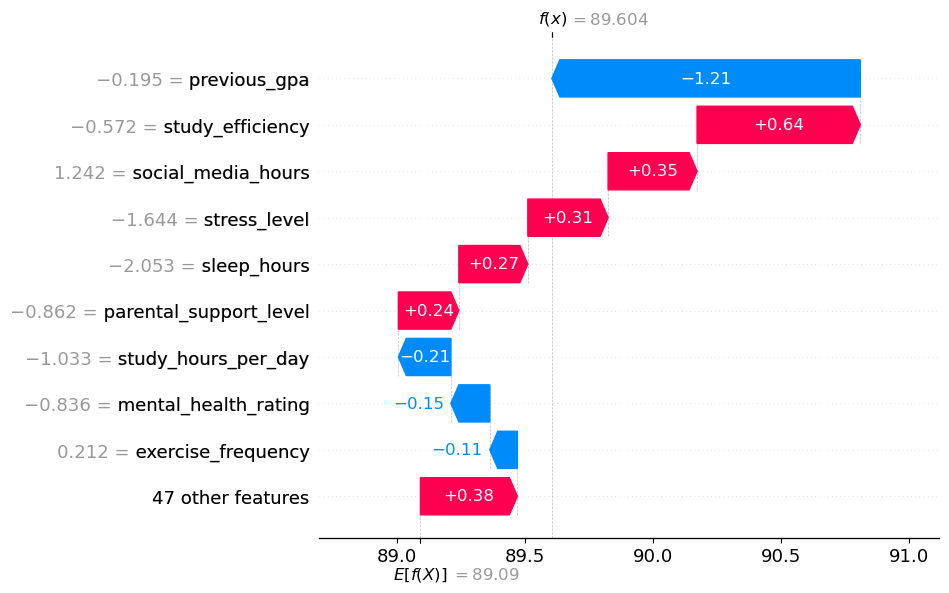

In [7]:
# pick the student whose predicted score is closest to the dataset mean — most representative
preds_sample = xgb_model.predict(X_sample)
mean_pred = preds_sample.mean()
most_typical_idx = abs(preds_sample - mean_pred).argmin()

print(f"explaining student at index {most_typical_idx} — predicted score: {preds_sample[most_typical_idx]:.1f}")
plot_waterfall(shap_values, idx=most_typical_idx, save_path="../data/processed/shap_waterfall.png")

## Interpretation
**Fill this in after the three plots render — don't pre-write conclusions.** Address:

- Does `previous_gpa` dominate the summary/bar plot as notebook 6's ablation finding predicted? What's the approximate ratio of its mean |SHAP| to the next-highest feature?
- Do any features show up higher in SHAP importance than in notebook 4's Random Forest importance ranking? If so, that's worth noting — the two methods answer slightly different questions.
- For the waterfall plot: what pushed this specific student's predicted score up or down relative to baseline? Does the direction of each feature's contribution make intuitive sense (e.g., high `study_hours` → positive push)?
- One sentence: does SHAP confirm or complicate the narrative that `previous_gpa` explains most of the signal?

In [8]:
with mlflow.start_run(run_name="shap_explainability"):
    mlflow.log_param("shap_sample_size", len(X_sample))
    mlflow.log_param("explained_model", "xgboost_regressor")
    mlflow.set_tag("experiment_stage", "explainability")
    mlflow.log_artifact("../data/processed/shap_summary.png")
    mlflow.log_artifact("../data/processed/shap_bar.png")
    mlflow.log_artifact("../data/processed/shap_waterfall.png")

print("SHAP artifacts logged to mlflow")

SHAP artifacts logged to mlflow


In [9]:
print("=" * 60)
print("  EXPLAINABILITY COMPLETE")
print("=" * 60)
print()
print("  three SHAP plots saved to data/processed/")
print("  artifacts logged to mlflow experiment 'student-success-platform'")
print()
print("  next: FastAPI layer (api/main.py + api/schemas.py)")

  EXPLAINABILITY COMPLETE

  three SHAP plots saved to data/processed/
  artifacts logged to mlflow experiment 'student-success-platform'

  next: FastAPI layer (api/main.py + api/schemas.py)
